In [ ]:
# KO/PEP Pairs Trading Project
# This notebook implements a pairs trading strategy for AMP/APO
# selected from the S&P 500 cointegration screen in screening.py
# We use mean reversion in the price spread between two 
# economically related assets (both asset management firms)

import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint # This is Engle-Granger cointegration test
import matplotlib.pyplot as plt
import datetime


# Step 1: Download data

# Load screened pairs from the screening pipeline and sort by OOS p-value
# (lower = stronger out-of-sample cointegration evidence)
df = pd.read_csv("screened_pairs.csv")
df = df.sort_values(by="coint_p_test")

# We choose AMP/APO: Ameriprise Financial / Apollo Global Management
# See README.md for rationale
s1 = "AMP"
s2 = "APO"
years = 5  # number of years of history to use

end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=365 * years)

# Download adjusted close prices (auto_adjust=True makes 'Close' already account for splits/dividends)
s1data = yf.download(s1, start=start_date, end=end_date, auto_adjust=True)
s2data = yf.download(s2, start=start_date, end=end_date, auto_adjust=True)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
# Log prices are used instead of raw prices because:
#   1. Log differences approximate percentage returns (additive, not multiplicative)
#   2. The cointegrating relationship is linear in logs: log(P_y) ≈ α + β·log(P_x)
#   3. OLS hedge ratio is more stable on log prices than raw prices

s1_log = np.log(s1data['Close'].squeeze()) # squeeze() converts single-column DataFrame to Series
s2_log = np.log(s2data['Close'].squeeze())
s1_log.name = s1
s2_log.name = s2

# Align to the intersection of trading days to handle situations where one market
# may have data and the other doesn't (such as different national holidays)
s1_log, s2_log = s1_log.align(s2_log, join='inner')

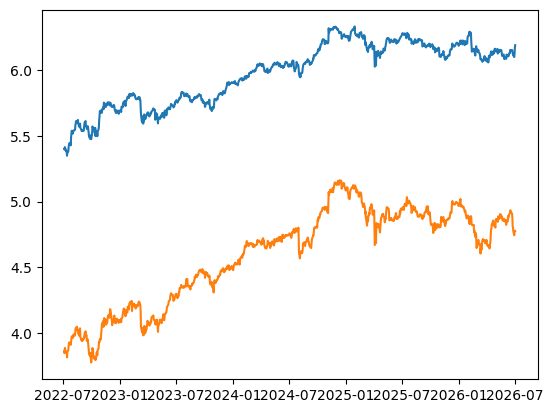

In [40]:
plt.plot(s1_log)
plt.plot(s2_log)
#plt.plot(s1data['Close'])
#plt.plot(s2data['Close'])
plt.legend
plt.show()

In [ ]:
# Engle-Granger cointegration test:
# Tests whether a linear combination of two non-stationary series is stationary.
# H0: no cointegration (spread has a unit root / diverges over time)
# H1: cointegration exists (spread is mean-reverting)
# p-value < 0.05 → reject H0 → evidence of cointegration → tradeable spread
coint_t, p_value, _ = coint(s1_log, s2_log)
print(f"Cointegration p-value for {s1}/{s2} (last {years} years): {p_value:.4f}")

# Optional: inspect log prices
print("\nSample log prices:")
print(pd.concat([s1_log, s2_log], axis=1).head())

Cointegration p-value for AMP/APO (last 4 years): 0.0051

Sample log prices:
                 AMP       APO
Date                          
2022-07-05  5.402990  3.860631
2022-07-06  5.395568  3.844246
2022-07-07  5.415491  3.884622
2022-07-08  5.408161  3.870180
2022-07-11  5.386234  3.853360


In [5]:
# OLS regression: AMP_log = α + β·APO_log + ε
# β (hedge ratio) tells us how many dollars of APO to short per dollar of AMP long,
# so that the resulting spread is dollar-neutral and stationary.
# sm.add_constant adds the intercept term α.
X = sm.add_constant(s2_log)   # independent variable (APO)
y = s1_log                    # dependent variable (AMP)

model = sm.OLS(y, X).fit()
hedge_ratio = model.params[s2]
print(f"\nHedge ratio ({s1}/{s2}): {hedge_ratio:.4f}")
# Interpretation: long $1 of AMP, short $0.645 of APO to form a stationary spread

# Construct spread: the residual from the regression
# If AMP and APO are cointegrated, this spread should be stationary (mean-reverting)
spread = y - hedge_ratio * s2_log


Hedge ratio (AMP/APO): 0.6441


In [6]:
# Standardise the spread into a z-score so entry/exit thresholds are
# expressed in units of standard deviations rather than raw log-price units.
# NOTE: using the full-sample mean and std here introduces a mild look-ahead bias
# (the mean/std use future data). backtest.py fixes this with a rolling window.
spread_mean = spread.mean()
spread_std  = spread.std()
zscore = (spread - spread_mean) / spread_std

signals = pd.DataFrame({
    f'{s1}_log': s1_log,
    f'{s2}_log': s2_log,
    'Spread':    spread,
    'Zscore':    zscore
})

print("\nSample spread and Z-score:")
print(signals.head())


Sample spread and Z-score:
             AMP_log   APO_log    Spread    Zscore
Date                                              
2022-07-05  5.402990  3.860631  2.916234 -1.977933
2022-07-06  5.395568  3.844246  2.919366 -1.916849
2022-07-07  5.415491  3.884622  2.913282 -2.035504
2022-07-08  5.408161  3.870180  2.915254 -1.997032
2022-07-11  5.386234  3.853360  2.904162 -2.213338


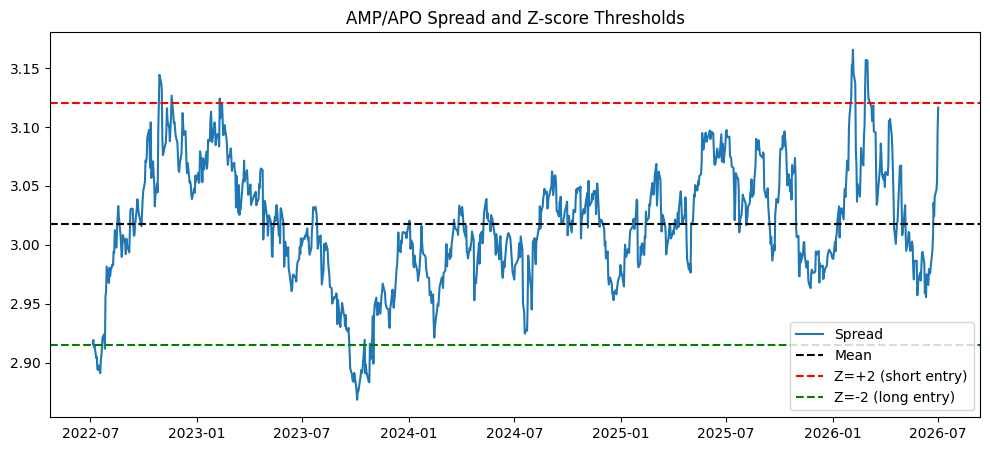

In [7]:
# Visualise the spread with entry/exit threshold bands.
# We enter a trade when the spread moves more than `threshold` std devs from its mean,
# and exit when it reverts back toward the mean.
threshold = 2  # number of standard deviations for entry signal

plt.figure(figsize=(12, 5))
plt.plot(spread, label='Spread')
plt.axhline(spread_mean,                       color='black', linestyle='--', label='Mean')
plt.axhline(spread_mean + threshold*spread_std, color='red',   linestyle='--', label=f'Z=+{threshold} (short entry)')
plt.axhline(spread_mean - threshold*spread_std, color='green', linestyle='--', label=f'Z=-{threshold} (long entry)')
plt.title(f'{s1}/{s2} Spread and Z-score Thresholds')
plt.legend()
plt.show()

In [8]:
# Generate trading signals based on the z-score:
#   +1  (long spread)  = buy AMP, short APO  → entered when z < -threshold (AMP is cheap)
#   -1  (short spread) = short AMP, buy APO  → entered when z > +threshold (AMP is dear)
#    0  (flat)         → exit when |z| < 0.5 (spread has reverted toward mean)
#
# The stateful loop ensures we hold a position until the exit condition is met,
# rather than re-evaluating entry/exit independently each day.
signals['long_entry']  = signals['Zscore'] < -threshold
signals['short_entry'] = signals['Zscore'] >  threshold
signals['exit']        = signals['Zscore'].abs() < 0.5

position  = 0
positions = []
for _, row in signals.iterrows():
    if row['exit']:
        position = 0         # close any open position
    elif row['long_entry']:
        position = 1         # enter long spread
    elif row['short_entry']:
        position = -1        # enter short spread
    positions.append(position)

signals['position'] = positions

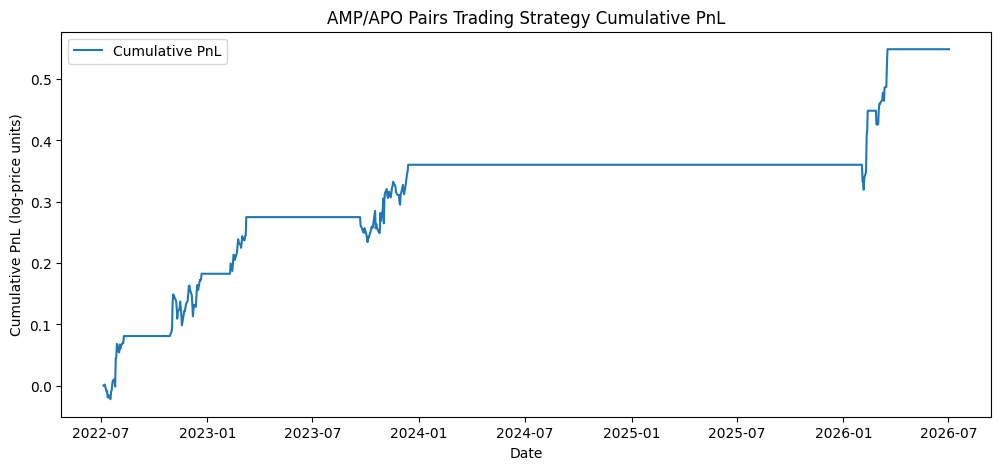

In [9]:
# ===============================
# Step 9: Backtest PnL
# ===============================
# Daily P&L = position_yesterday × change_in_spread_today
# position.shift(1) implements the 1-day execution lag: today's signal
# is acted on at tomorrow's open (approximated as tomorrow's close).
# This avoids look-ahead bias in the P&L calculation.
spread_ret = signals['Spread'].diff()            # daily change in spread (log-price units)
signals['PnL']            = signals['position'].shift(1) * spread_ret
signals['Cumulative_PnL'] = signals['PnL'].cumsum()

# Cumulative PnL is in log-price units (not dollars or percent).
# A rising curve means the strategy is profiting from spread mean reversion.
plt.figure(figsize=(12, 5))
plt.plot(signals['Cumulative_PnL'], label='Cumulative PnL')
plt.title(f'{s1}/{s2} Pairs Trading Strategy Cumulative PnL')
plt.xlabel('Date')
plt.ylabel('Cumulative PnL (log-price units)')
plt.legend()
plt.show()

In [10]:
# ===============================
# Step 10: Performance metrics
# ===============================
# Sharpe ratio: annualised mean return divided by annualised volatility.
# A Sharpe > 1 is generally considered good; > 2 is excellent.
# Multiplying by sqrt(252) annualises the daily ratio.
# NOTE: no transaction costs are modelled here — backtest.py includes costs.
sharpe = signals['PnL'].mean() / signals['PnL'].std() * np.sqrt(252)

# Count round-trip trades: each entry+exit pair = 1 trade.
# diff().abs() flags days where the position changed; dividing by 2
# converts position changes into round-trips.
num_trades = signals['position'].diff().abs().sum() / 2

print(f"\nSharpe ratio: {sharpe:.2f}")
print(f"Number of trades: {num_trades}")


Sharpe ratio: 1.56
Number of trades: 6.0
